# Generalized calibration with L2 and L1

In this notebook, you will:
- choose which specimens enter a **joint** fit (and their relative weights)
- choose **validation** specimens the fit never sees (metrics and overlays only)
- set shared SteelMPF seeds / free parameters
- optimize **two** recipes in one run: L2 (`set_id=1`) and L1 (`set_id=3`)
- compare train vs validation scores, then plot overlays (optional focus Name first)

**Requirement:** each train Name needs path-ordered resampled data
(`data/resampled/{Name}/force_deformation.csv`). Digitized unordered specimens
cannot enter the joint fit, but they can be validation checks (via `J_binenv`).
Catalog `generalized_weight` is ignored here — use `TRAIN_SPECIMENS` weights
instead (default 1).

Defaults in the Parameters cell are one useful split; edit Names and weights
freely.

Edit the **Parameters** cell, then run the remaining cells in order.

Outputs: `results/notebooks/generalized_l2_l1/`.

### Optional: faster batch run

If this notebook is too slow, use the automated pipeline from the repo root
(`./run.sh` or `.\run.ps1`). Who trains vs who is validation-only is the
`generalized_weight` column in `config/calibration/BRB-Specimens.csv`
(**1** = train, **0** = validation scored after the fit). L2 / L1 recipes live
in `config/calibration/set_id_settings_generalized.csv`.


## Browse the specimen catalog

Before you pick a specimen name, look at what is in the repo:

- a **table** from `config/calibration/BRB-Specimens.csv` (geometry + layout flags)
- a **grid of raw hysteresis** from `data/raw/{Name}/` (unfiltered)

Path-ordered tests draw as loops; digitized tests draw as points.
Then edit **Parameters** below and choose a `Name` you like.


,Name,experimental_layout,path_ordered,fyp,A_sc,A_t,L_T,L_y,individual_optimize,generalized_weight
0,PC250,raw,true,41.30,5.96,59.60,251.96,179.40,true,1
1,PC350,raw,true,41.30,8.34,83.40,252.02,183.30,true,1
2,PC160,raw,true,41.30,3.80,38.00,252.00,176.00,true,1
3,PC500,raw,true,37.90,12.66,126.60,251.98,185.10,true,1
4,PC750A,raw,true,37.90,17.85,178.50,251.98,184.20,true,1
5,PC750B,raw,true,37.90,17.87,178.70,251.96,179.40,true,1
6,PC1200A,raw,true,37.90,28.53,285.30,252.02,185.20,true,1
7,PC1200B,raw,true,37.90,28.62,286.20,251.96,181.30,true,1
8,PC3SB,digitized,true,40.00,5.00,50.00,116.00,78.00,true,0
9,A5,digitized,false,44.08,5.66,56.60,215.55,148.70,false,0


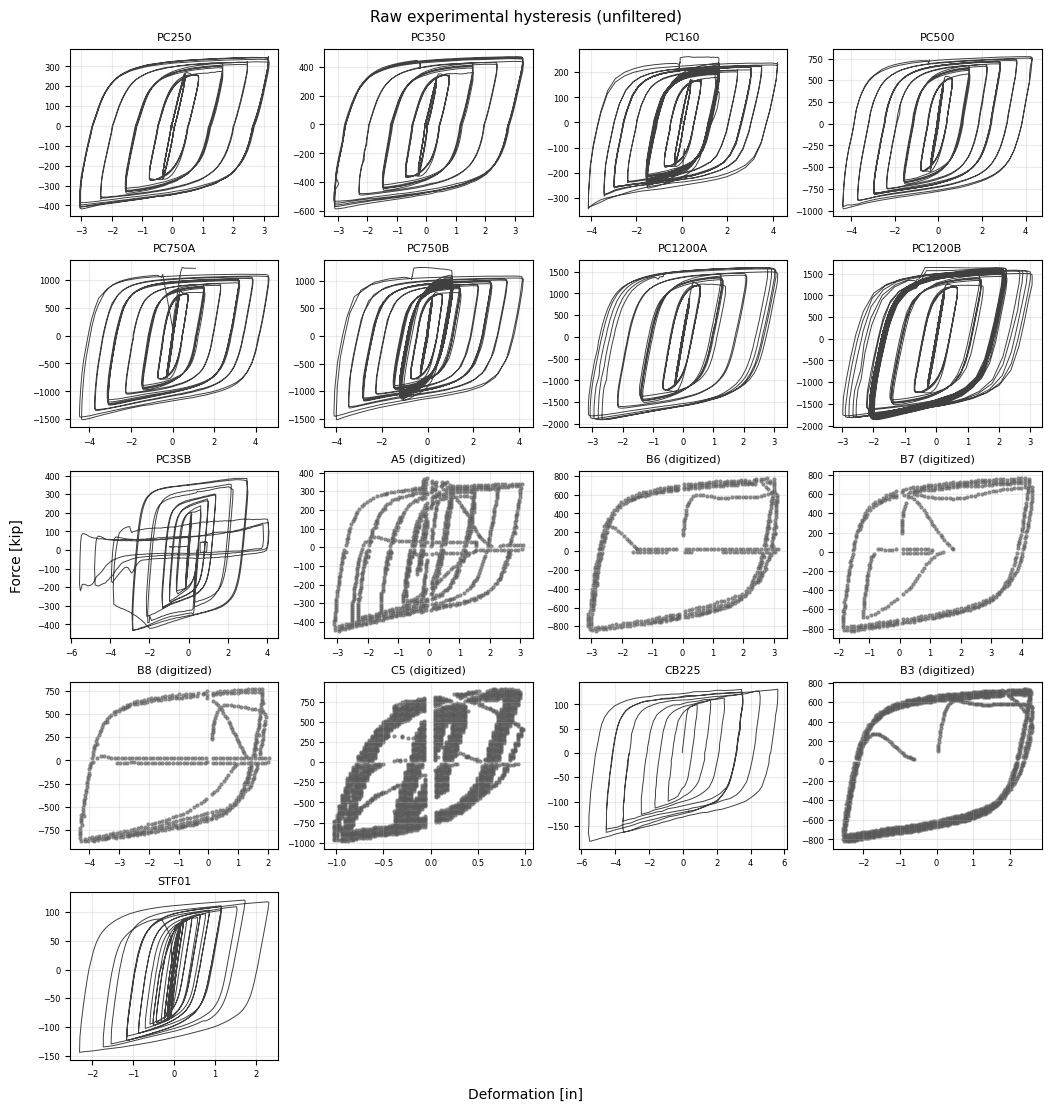

catalog rows: 17


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import show_specimen_catalog  # noqa: E402

catalog = show_specimen_catalog()
print("catalog rows:", len(catalog))


## What the objective measures

We ask the optimizer to make the model hysteresis look like the experiment.
It does that by minimizing a **weighted sum** of a few error terms:

`J_total = Σ w_k · metric_k`

| Weight | Plain-language meaning |
|--------|------------------------|
| `w_feat_l2` / `w_feat_l1` | How much the fit weights L2 vs L1 error on the **important points** of each cycle (peaks, unload, re-yield). Demos usually put all the weight on one (set it to 1, the other to 0). |
| `w_energy_l2` / `w_energy_l1` | How well per-cycle **energy** (abs of `∫ F du`) matches. Usually left at 0. |
| `w_unordered_binenv_l2` / `w_unordered_binenv_l1` | How well the **outer force envelope** matches when you only have a cloud of `(D, F)` points (digitized tests). Usually weight 0 in the fit; still reported as a diagnostic. |

Even when a weight is 0, the metrics tables still **print** that column so you can look at it.

## Amplitude weighting (inside the point-match term)

These settings do **not** add a new term. They only change how cycles are mixed
**inside** the characteristic-point error `J_feat`:

`J_feat = Σ_c w_c · j_c / Σ_c w_c`

| Setting | Effect |
|---------|--------|
| `use_amplitude_weights=False` | Every cycle counts equally (`w_c = 1`). |
| `use_amplitude_weights=True` | Larger cycles count more: `w_c = (A_c / A_max)^p + ε`. |
| `amplitude_weight_power` (`p`) | How strongly amplitude boosts the weight. |
| `amplitude_weight_eps` (`ε`) | Small floor so tiny cycles are not ignored completely. |


## What the calibration settings mean

These notebooks run **one configuration at a time** (one specimen list + one
SteelMPF / loss recipe). The automated pipeline does the same idea over the full
catalog, often with two recipes (e.g. `set_id=1` for L2, `set_id=3` for L1).

| Setting | Meaning |
|---------|---------|
| **`set_id`** | Integer tag for this run so results do not overwrite each other. Example: an L2-based optimization as `set_id=1`, another (L1) as `set_id=3`. |
| **`inherit_from_set`** | `-999` (or blank) = start from the **seeds** below. Otherwise reuse the **optimized parameters** from that other `set_id` as this run’s starting point, then change whatever you want here (loss weights, which params are free, seeds for params that stay fixed, …). |
| **Seeds** (`E`, `b_p`, `b_n`, `R0`, …) | Starting SteelMPF values when you are not inheriting. Parameters **not** listed in `optimize_params` stay fixed at these seeds. Free parameters **start** here (or from the inherited set) and move during L-BFGS-B. |
| **`optimize_params`** | Which SteelMPF names the optimizer may change. Everything else stays at its seed (or inherited value). |
| **`w_feat_l2` / `w_feat_l1`** | How much the objective weights L2 vs L1 error on characteristic points. `1` and `0` means “all L2”; swap them for all L1; both nonzero mixes the two. |
| **`b_p` / `b_n` seeds** | A numeric guess, or a keyword that **extracts** the value from the experimental hysteresis cycles: `median` (across cycles), `mean`, `weighted_mean`, plus `q1`, `q3`, `min`, `max`, … |

### Common edits (copy into the Parameters cell)

**Free a different parameter set**

```python
# Fewer free params (pipeline individual default style):
OPTIMIZE_PARAMS = ["cR1", "cR2", "a1", "a3"]
# More free params (single-specimen / generalized demo style):
# OPTIMIZE_PARAMS = ["b_p", "b_n", "R0", "cR1", "cR2", "a1", "a3"]
```

**Run L2, then L1** (like pipeline `set_id=1` then `set_id=3`)

```python
# set_id = 3          # optional label for outputs
# w_feat_l2 = 0
# w_feat_l1 = 1
```

Run once with L2 / `set_id=1` (the defaults). To add an L1 pass, change the loss
weights and `set_id` to 3 and run again. Optionally set `inherit_from_set=1` on
the second pass so L1 starts from the L2 result.


## What `J_binenv` is

Some validation specimens are **digitized clouds**: many `(deformation, force)`
points with no reliable cycle-by-cycle time order. For those, the usual
characteristic-point score is not a fair comparison.

`J_binenv` (binned envelope) is the alternative:

1. Slice the deformation axis into bins.
2. In each bin, read the **highest** and **lowest** force on the experiment and
   on the model.
3. Score how well those upper/lower envelopes match.

So: **for digitized validation, look at `J_binenv` first.** Path-ordered
specimens also report it, which makes train vs validation easier to compare on
one scale. (The fit usually leaves the binenv **weight** at 0; the column is
still filled for reporting.)


## Parameters

- **`TRAIN_SPECIMENS`** — who enters the joint fit, and with what relative weight.
- **`VALIDATION_SPECIMENS`** — built from `FOCUS_VALIDATION` plus
  `EXTRA_VALIDATION`: metrics and overlays only (weight 0).
- **`FOCUS_VALIDATION`** — plotted first in the results section (any validation
  Name; keep it out of `TRAIN_SPECIMENS` if you want a true check).
- **`SET_ID_ROWS`** — shared seeds / free params with two loss recipes (L2 then
  L1) in one optimizer call.

Change Names, weights, or recipes below, then run all cells under this one.


In [2]:
from pathlib import Path
import sys

# --- edit these ---
FOCUS_VALIDATION = "PC3SB"
# Extra validation (not in the joint fit). B6 / A5 = digitized clouds;
# CB225 = path-ordered digitized with a growing multi-amplitude protocol.
EXTRA_VALIDATION = ["CB225", "B6", "A5"]
PREPARE_DATA = True

# Name -> specimen weight in the joint objective (default 1).
TRAIN_SPECIMENS = {
    "PC250": 1.0,
    "PC350": 1.0,
    "PC500": 1.0,
    "PC160": 1.0,
    "PC750A": 1.0,
    "PC750B": 1.0,
    "PC1200A": 1.0,
    "PC1200B": 1.0,
}
# Too slow? Prefer the automated pipeline (./run.sh or .\run.ps1) and set
# generalized_weight in config/calibration/BRB-Specimens.csv
# (1 = train, 0 = validation only).

# Shared SteelMPF seeds / free params; only loss weights and set_id differ below.
_STEEL = {
    "E": 29000,
    "b_p": 0.005,   # numeric guess, or extract from cycles: "median", "mean", "weighted_mean", ...
    "b_n": 0.025,
    "R0": 20,
    "cR1": 0.8875,
    "cR2": 0.15,
    "a1": 0.04,
    "a2": 1.0,
    "a3": 0.04,
    "a4": 1.0,
    "optimize_params": ["b_p", "b_n", "cR1", "cR2", "a1", "a3"],
    "w_energy_l2": 0,
    "w_energy_l1": 0,
    "w_unordered_binenv_l2": 0,
    "w_unordered_binenv_l1": 0,
    "use_amplitude_weights": True,
    "amplitude_weight_power": 2,
    "amplitude_weight_eps": 0.05,
}

SET_ID_ROWS = [
    {**_STEEL, "set_id": 1, "inherit_from_set": -999, "w_feat_l2": 1, "w_feat_l1": 0},
    {**_STEEL, "set_id": 3, "inherit_from_set": -999, "w_feat_l2": 0, "w_feat_l1": 1},
]
# ------------------

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
from notebook_support import (  # noqa: E402
    NOTEBOOK_RESULTS,
    digitized_unordered_sim_arrays,
    ensure_sys_path,
    load_experiment_force_disp,
    params_dict_from_row,
    run_generalized_demo,
    simulate_force_disp,
    summarize_generalized_train_validation_metrics,
)
ensure_sys_path()

VALIDATION_SPECIMENS = [FOCUS_VALIDATION] + [n for n in EXTRA_VALIDATION if n != FOCUS_VALIDATION]
assert FOCUS_VALIDATION not in TRAIN_SPECIMENS, FOCUS_VALIDATION
print("train:", TRAIN_SPECIMENS)
print("validation (focus first):", VALIDATION_SPECIMENS)
print("set_ids:", [r["set_id"] for r in SET_ID_ROWS])


train: {'PC250': 1.0, 'PC350': 1.0, 'PC500': 1.0, 'PC160': 1.0, 'PC750A': 1.0, 'PC750B': 1.0, 'PC1200A': 1.0, 'PC1200B': 1.0}
validation (focus first): ['PC3SB', 'CB225', 'B6', 'A5']
set_ids: [1, 3]


## Run the joint fits

Learns **one** shared SteelMPF vector from the weighted train list for each
`set_id` row (here: L2, then L1), then scores train and validation specimens.
Validation Names never enter the fit — they are a check afterward.


In [3]:
paths = run_generalized_demo(
    TRAIN_SPECIMENS,
    set_id_row=SET_ID_ROWS,
    eval_specimens=VALIDATION_SPECIMENS,
    prepare_data=PREPARE_DATA,
    work_dir=NOTEBOOK_RESULTS / "generalized_l2_l1",
)
print("params: ", paths["params"])
print("metrics:", paths["metrics"])
print("plots:  ", paths["plots_dir"])
print("set_ids:", paths.get("set_ids"))
print("train:  ", paths["train_weights"])
print("validation:", paths.get("validation_specimens", paths["eval_specimens"]))


Preparing data for 'PC250'...
  Preparing data for 'PC250'...
    cycle_points: 132 points, 132 segments (wrote JSON)
Skip filtering PC250: min segment length 1 < 11


Wrote data\filtered\PC250/{force_deformation,deformation_history}.csv
    filter_force: done


  PC250: resampled n=2060 (filtered n=16325), D_sampling=0.066456 in
    resample_filtered: done
Preparing data for 'PC350'...
  Preparing data for 'PC350'...
    cycle_points: 134 points, 134 segments (wrote JSON)
Skip filtering PC350: min segment length 4 < 11


Wrote data\filtered\PC350/{force_deformation,deformation_history}.csv
    filter_force: done


  PC350: resampled n=2012 (filtered n=17500), D_sampling=0.0677078 in
    resample_filtered: done
Preparing data for 'PC500'...
  Preparing data for 'PC500'...
    cycle_points: 160 points, 160 segments (wrote JSON)
Skip filtering PC500: min segment length 5 < 11


...

    cycle_points: 91 points, 91 segments (wrote JSON)
Skip filtering PC3SB: min segment length 6 < 11


Wrote data\filtered\PC3SB/{force_deformation,deformation_history}.csv
    filter_force: done


  PC3SB: resampled n=2487 (filtered n=99649), D_sampling=0.0282069 in
    resample_filtered: done
Preparing data for 'CB225'...
  Preparing data for 'CB225'...
    cycle_points: 46 points, 46 segments (wrote JSON)
CB225: skip_filter_resample -> filtered = trim-valid raw (no Savitzky-Golay)
Wrote data\filtered\CB225/{force_deformation,deformation_history}.csv
    filter_force: done


  CB225: resampled n=1514 (filtered n=486), D_sampling=0.0682067 in
    resample_filtered: done
+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\optimize_generalized_brb_mse.py --set-id-settings C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\set_id_settings_generalized.csv --train-specimens PC250:1,PC350:1,PC500:1,PC160:1,PC750A:1,PC750B:1,PC1200A:1,PC1200B:1 --output-params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\generalized_brb_parameters.csv --output-metrics C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\generalized_params_eval_metrics.csv --output-plots-dir C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\overlays --output-cloud-plots-dir C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\overlays --eval-specimens PC3SB,CB2

params:  C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\generalized_brb_parameters.csv
metrics: C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\generalized_params_eval_metrics.csv
plots:   C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized_l2_l1\overlays
set_ids: [1, 3]
train:   {'PC250': 1.0, 'PC350': 1.0, 'PC500': 1.0, 'PC160': 1.0, 'PC750A': 1.0, 'PC750B': 1.0, 'PC1200A': 1.0, 'PC1200B': 1.0}
validation: ['PC3SB', 'CB225', 'B6', 'A5']


## Results — train vs validation

The table tags each Name as **train** or **validation**, for each `set_id` that
was run.

- **`J_feat`** — characteristic-point match (what the fit usually minimizes).
- **`J_binenv`** — envelope match (especially useful for digitized clouds).

Rule of thumb: train specimens should tend to look **better** (lower scores)
than validation specimens the model has not seen.

Overlays below plot experiment vs model for validation Names (`FOCUS_VALIDATION`
first), then the other validation Names, then train Names.


,Name,set_id,role,J_feat,J_binenv,J_total,specimen_weight
0,PC1200A,1,train,0.000238,0.000807,0.000238,1.0
1,PC1200B,1,train,0.000130,0.000643,0.000130,1.0
2,PC160,1,train,0.000500,0.000949,0.000500,1.0
3,PC250,1,train,0.000157,0.000498,0.000157,1.0
4,PC350,1,train,0.000272,0.000825,0.000272,1.0
5,PC500,1,train,0.000131,0.000319,0.000131,1.0
6,PC750A,1,train,0.000314,0.001156,0.000314,1.0
7,PC750B,1,train,0.000468,0.001540,0.000468,1.0
8,A5,1,validation,NaN,0.004172,NaN,0.0
9,B6,1,validation,NaN,0.005425,NaN,0.0


Focus validation: PC3SB


,Name,set_id,role,J_feat,J_binenv,J_total,specimen_weight
11,PC3SB,1,validation,0.000964,0.002234,0.000964,0.0
23,PC3SB,3,validation,0.001131,0.002605,0.024961,0.0


=== Validation overlays (focus first) ===


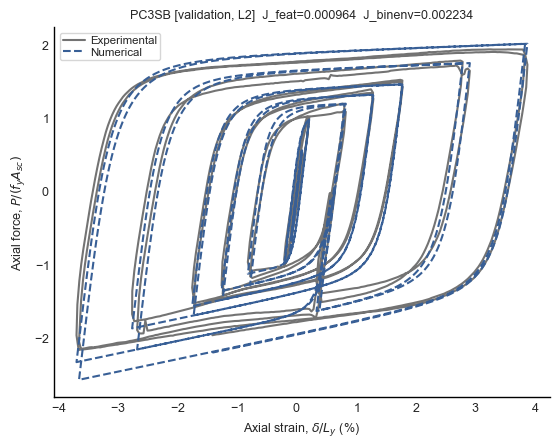

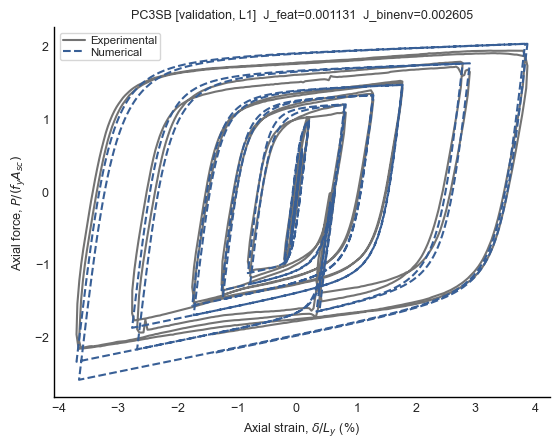

=== Other validation overlays ===


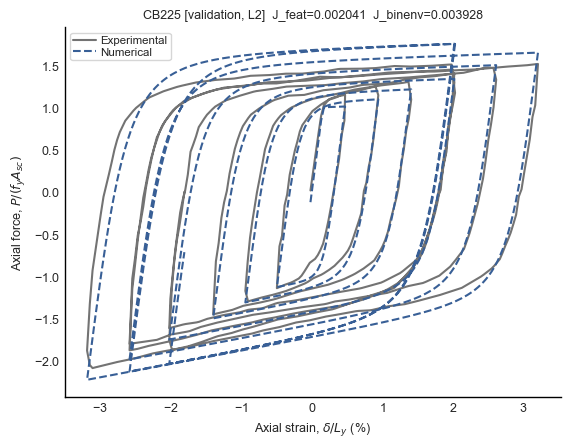

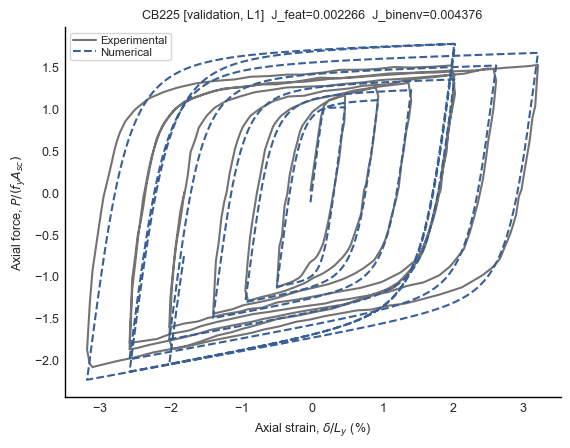

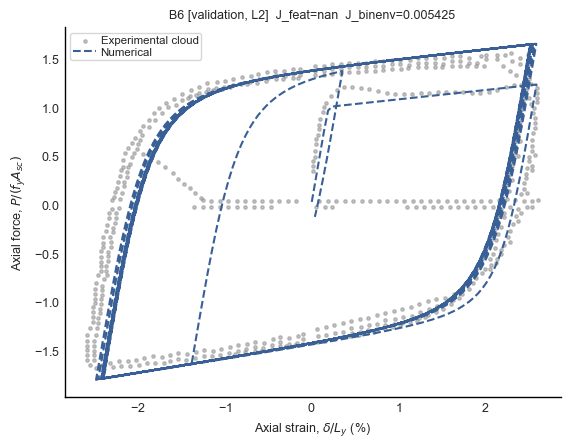

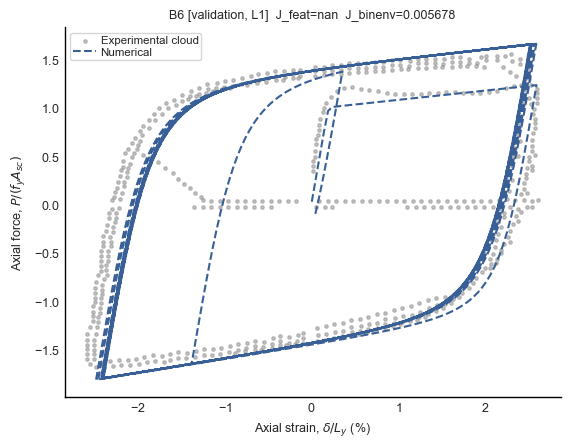

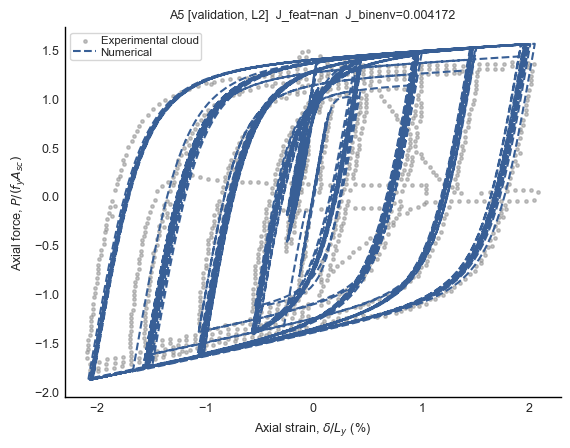

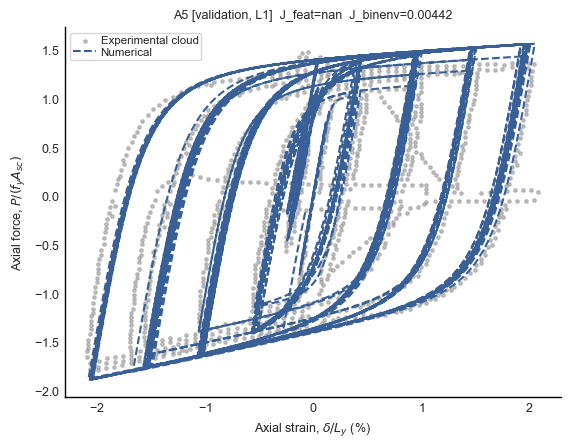

=== Train overlays ===


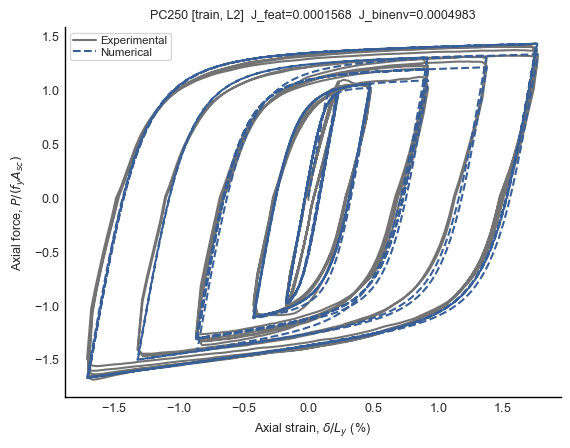

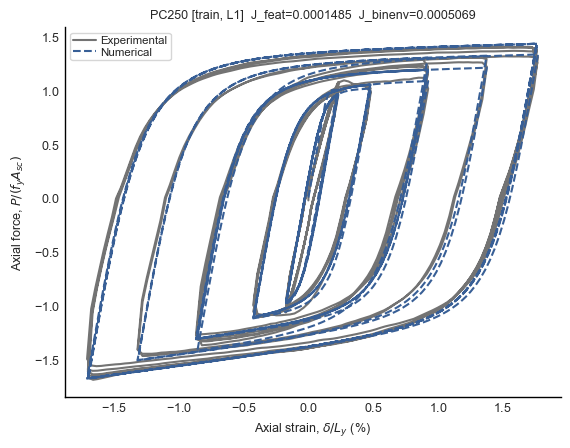

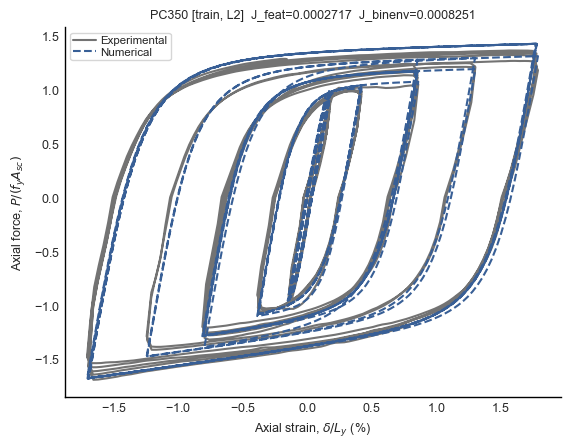

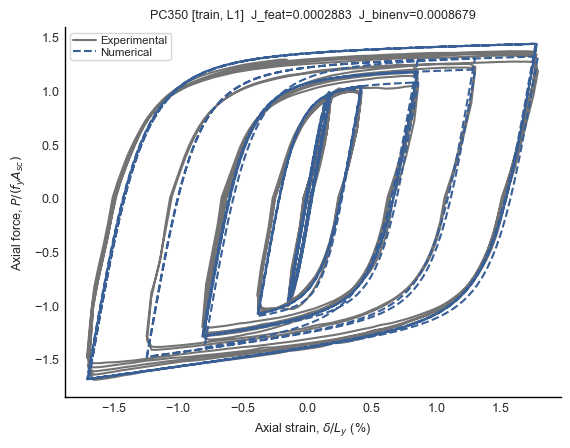

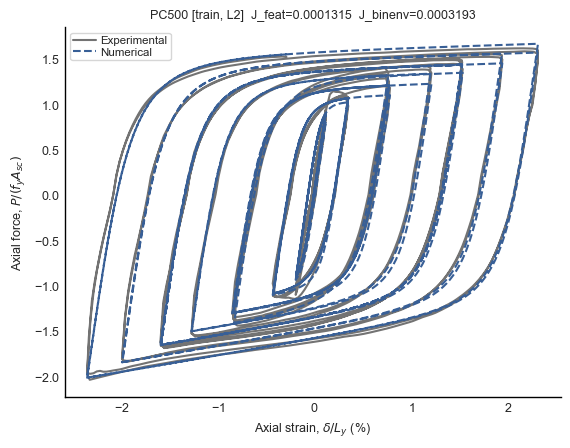

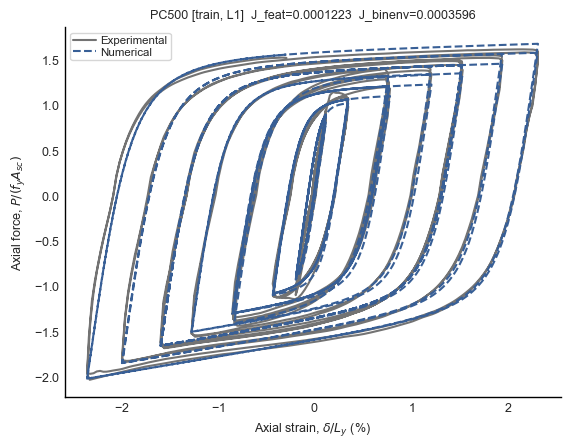

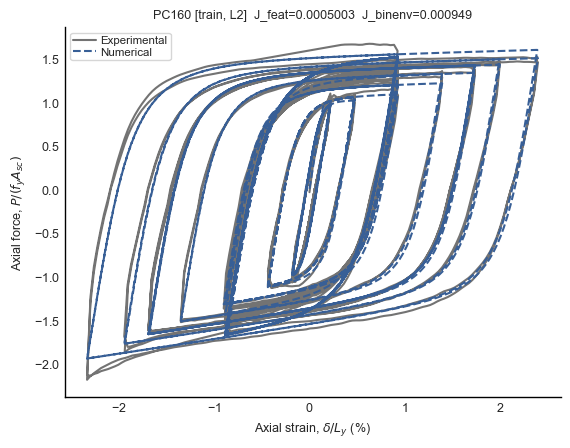

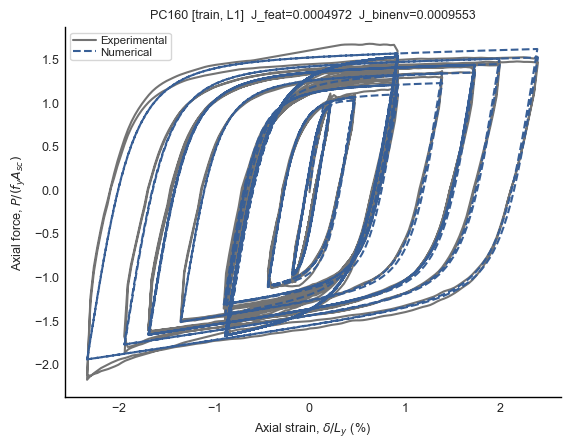

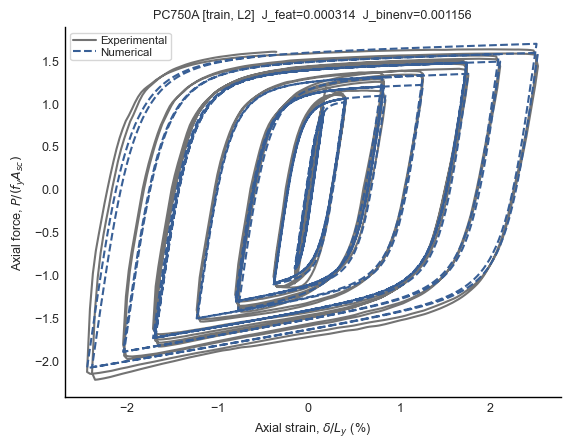

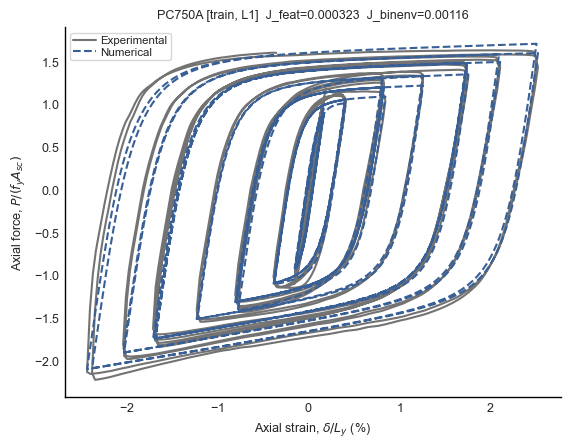

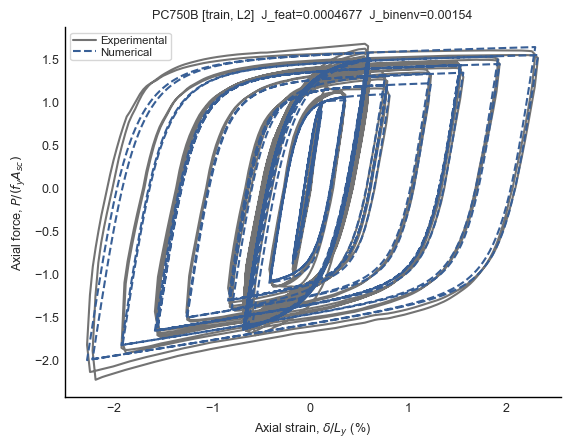

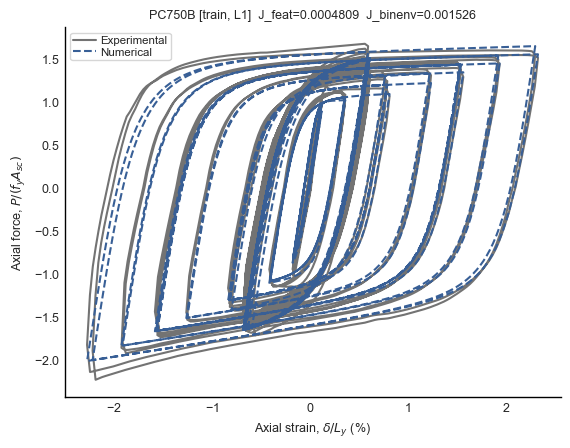

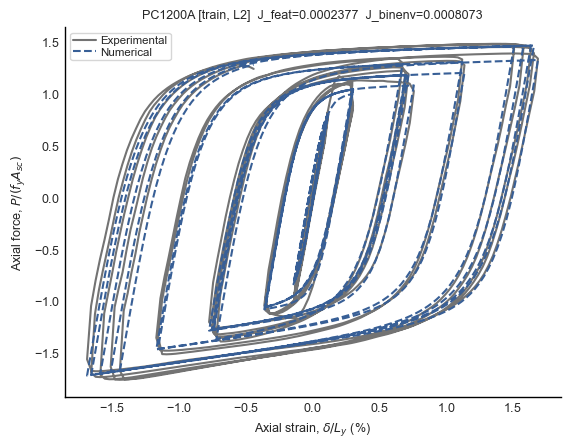

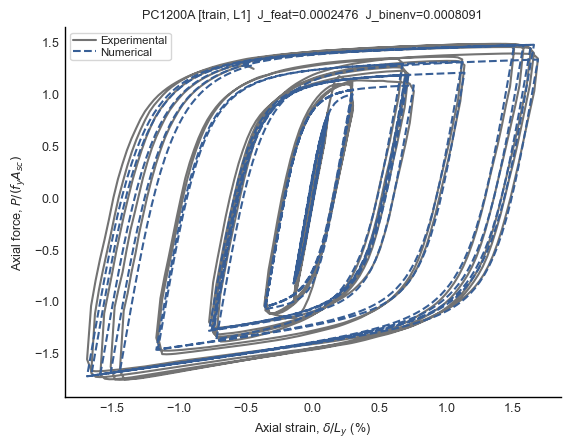

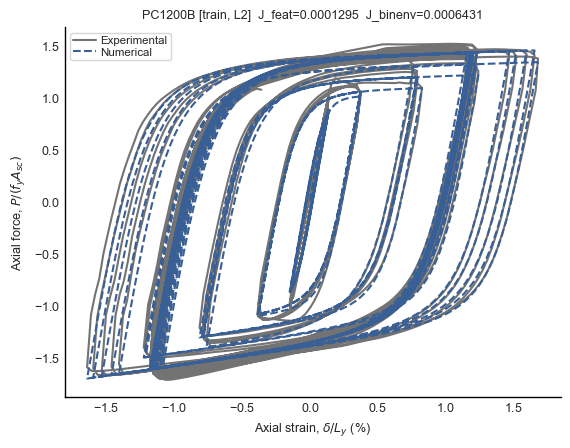

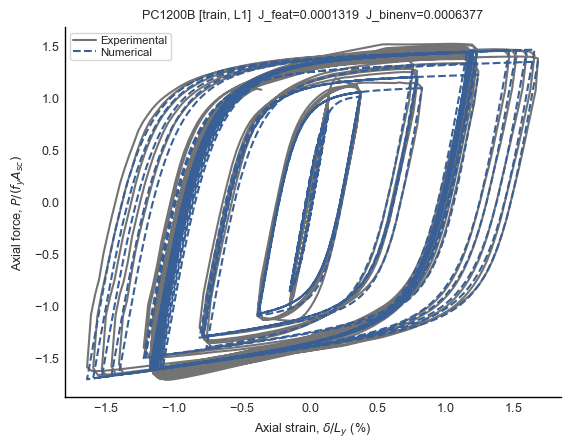

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from specimen_catalog import get_specimen_record, read_catalog, uses_unordered_inputs

params = pd.read_csv(paths["params"])
metrics = pd.read_csv(paths["metrics"])

cmp = summarize_generalized_train_validation_metrics(
    metrics,
    train_names=list(TRAIN_SPECIMENS),
    eval_names=VALIDATION_SPECIMENS,
)
display(cmp)

focus = cmp[cmp["Name"].astype(str) == FOCUS_VALIDATION]
print(f"Focus validation: {FOCUS_VALIDATION}")
display(focus)

set_ids = [int(r["set_id"]) for r in SET_ID_ROWS]
_cat = read_catalog()


def _overlay(name: str, sid: int, role: str) -> None:
    rows = params[(params["Name"].astype(str) == name) & (params["set_id"] == sid)]
    if rows.empty:
        print(f"(skip {name} set_id={sid}: no params row)")
        return
    p = params_dict_from_row(rows.iloc[0])
    jrow = cmp[(cmp["Name"].astype(str) == name) & (cmp["set_id"] == sid)]
    j_feat = float(jrow["J_feat"].iloc[0]) if len(jrow) else float("nan")
    j_bin = float(jrow["J_binenv"].iloc[0]) if len(jrow) else float("nan")
    loss = "L2" if sid == 1 else ("L1" if sid == 3 else f"set{sid}")
    fyA = p["fyp"] * p["A_sc"]
    plt.figure()
    if uses_unordered_inputs(get_specimen_record(name, _cat)):
        dig = digitized_unordered_sim_arrays(name, p)
        plt.scatter(
            100.0 * dig["u_cloud"] / p["L_y"],
            dig["F_cloud"] / fyA,
            s=6,
            c="0.55",
            alpha=0.5,
            label="Experimental cloud",
        )
        plt.plot(
            100.0 * dig["D_drive"] / p["L_y"],
            dig["F_sim"] / fyA,
            linestyle="--",
            label="Numerical",
        )
    else:
        exp_disp, exp_force = load_experiment_force_disp(name)
        num_disp, num_force = simulate_force_disp(exp_disp, **p)
        plt.plot(100.0 * exp_disp / p["L_y"], exp_force / fyA, color="0.45", label="Experimental")
        plt.plot(100.0 * num_disp / p["L_y"], num_force / fyA, linestyle="--", label="Numerical")
    plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
    plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
    plt.title(f"{name} [{role}, {loss}]  J_feat={j_feat:.4g}  J_binenv={j_bin:.4g}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


print("=== Validation overlays (focus first) ===")
for sid in set_ids:
    _overlay(FOCUS_VALIDATION, sid, "validation")

print("=== Other validation overlays ===")
for name in VALIDATION_SPECIMENS:
    if name == FOCUS_VALIDATION:
        continue
    for sid in set_ids:
        _overlay(name, sid, "validation")

print("=== Train overlays ===")
for name in TRAIN_SPECIMENS:
    for sid in set_ids:
        _overlay(name, sid, "train")
